In [1]:
import sys
sys.path.insert(1, '../src/')
from data_utils import *
from train_and_evaluate import *
np.set_printoptions(suppress=True)

import json

with open('../config.json', 'r') as f:
    config = json.load(f)

ELEMENTS_TO_KEEP = config["elements_to_keep"]
ELEMENTS_TO_KEEP_NO_FE = [el for el in ELEMENTS_TO_KEEP if el != 'Fe']
NORMALISATION_TO_FE = config["normalisation_to_Fe"]

PREDICTION_PATH_DICT = config["prediction_path"]
PREPROCESSED_DATA_PATH_DICT = config["preprocessed_data_path"]
FIGURES_PATH = config["figures_path"]['all']

DATASETS = ['Konstytucja', 'corroded', 'Merkuriusz', 'Kopernik']

CMAP = plt.get_cmap('tab20')

In [2]:
df, y_true = join_datasets_into_one(
                            DATASETS, 
                            PREDICTION_PATH_DICT,
                            PREPROCESSED_DATA_PATH_DICT,
                            ELEMENTS_TO_KEEP_NO_FE if NORMALISATION_TO_FE else ELEMENTS_TO_KEEP
                            )

X = np.array(df.values)

In [3]:
from sklearn.decomposition import PCA

n_components = 3
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X)

In [4]:
# principal components, i.e. directions of the greatest variance in space (perpendicular to one another)
pca.components_

array([[-0.00292304,  0.12571896, -0.17408311,  0.38863262,  0.43133281,
         0.40846067,  0.59896285,  0.04379607,  0.19918214,  0.13299589,
         0.06671323,  0.16574427],
       [-0.11621012, -0.46253929, -0.29128221, -0.01097115, -0.21107453,
         0.46715436,  0.09691352,  0.16791403, -0.15062535, -0.23568533,
        -0.38148093, -0.40429031],
       [ 0.12906633, -0.05331892,  0.2814238 , -0.04472358,  0.01059179,
         0.1652421 , -0.20831647,  0.83600454,  0.33378978,  0.07361787,
         0.10661131,  0.03717202]])

In [5]:
pca.components_[0,:] #PC1

array([-0.00292304,  0.12571896, -0.17408311,  0.38863262,  0.43133281,
        0.40846067,  0.59896285,  0.04379607,  0.19918214,  0.13299589,
        0.06671323,  0.16574427])

In [6]:
pca.components_[1,:] #PC2

array([-0.11621012, -0.46253929, -0.29128221, -0.01097115, -0.21107453,
        0.46715436,  0.09691352,  0.16791403, -0.15062535, -0.23568533,
       -0.38148093, -0.40429031])

In [7]:
pca.components_[2,:] #PC3

array([ 0.12906633, -0.05331892,  0.2814238 , -0.04472358,  0.01059179,
        0.1652421 , -0.20831647,  0.83600454,  0.33378978,  0.07361787,
        0.10661131,  0.03717202])

In [8]:
# principal components, i.e. directions of the greatest variance in space (perpendicular to one another)
pca.explained_variance_ratio_

array([0.51347053, 0.14999472, 0.10589529])

In [9]:
# elements corresponding to consecutive dimensions
print(ELEMENTS_TO_KEEP_NO_FE if NORMALISATION_TO_FE else ELEMENTS_TO_KEEP)

['Al', 'S', 'Cr', 'Mn', 'Co', 'Cu', 'Zn', 'Pb', 'Fe', 'Mg', 'Na', 'K']


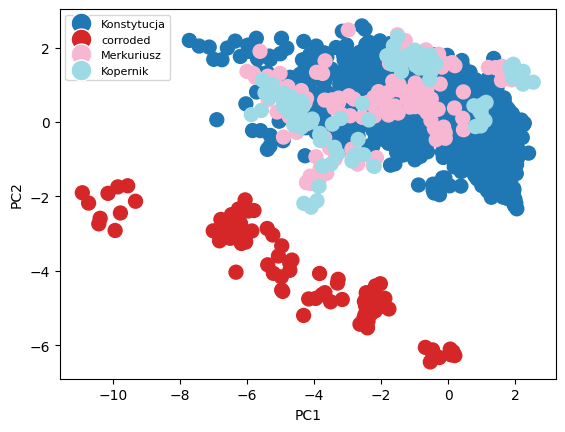

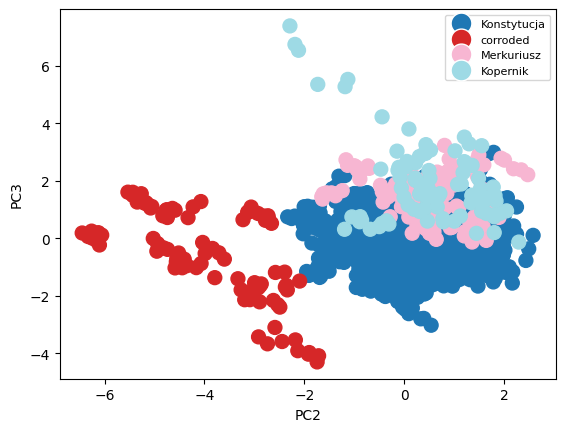

In [10]:
visualise_pca(X_pca, y_true, dimensions=[0,1], whether_sort=False, figures_path=None)

visualise_pca(X_pca, y_true, dimensions=[1, 2], whether_sort=False, figures_path=None)